# Fradara — Anomaly Detection Model
## AI-Powered Fraud Detection Platform for Corporate Expense & Procurement

**Model:** Isolation Forest + Autoencoder Neural Network (Weighted Ensemble)  
**Dataset:** 5.000 transaksi sintetis (4.500 normal, 500 fraud)  
**Pipeline:** Train → Val → Test (no leakage, threshold dari val set)

## Step 0 — Import & Konfigurasi

In [2]:
import os, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.preprocessing   import StandardScaler, MinMaxScaler
from sklearn.ensemble        import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (
    confusion_matrix, roc_auc_score, f1_score,
    precision_score, recall_score, accuracy_score,
    average_precision_score, precision_recall_curve,
    roc_curve, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.get_logger().setLevel("ERROR")

# ── Konfigurasi visual ──────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "font.family"      : "sans-serif",
    "font.size"        : 11,
})
PALETTE = {"normal": "#1D9E75", "fraud": "#E24B4A", "iso": "#378ADD", "ae": "#7F77DD", "ens": "#D85A30"}

# ── Path ────────────────────────────────────────────────────────
BASE_DIR   = Path("fradara_anomaly_dataset.csv").resolve().parent
INPUT_FILE = BASE_DIR / "fradara_anomaly_dataset.csv"
OUT_DIR    = BASE_DIR / "fradara_output"
OUT_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

FEATURE_COLS = [
    "amountTotal", "unitPrice", "quantity",
    "log_amount", "log_unitprice",
    "amount_zscore", "amount_vs_category_median",
    "amount_consistency_ratio", "amount_vs_employee_avg",
    "purchase_month", "purchase_dayofweek", "purchase_quarter", "is_weekend",
    "days_to_approval", "days_purchase_to_invoice",
    "days_invoice_to_payment", "vendor_age_at_contract",
    "employee_daily_tx", "vendor_tx_count",
    "invoice_frequency", "employee_tx_frequency",
    "transaction_type_enc", "department_enc", "location_enc",
    "category_enc", "itemDescription_enc", "status_enc",
]

print(f"Setup selesai ✓ | TF {tf.__version__} | Features: {len(FEATURE_COLS)}")

Setup selesai ✓ | TF 2.20.0 | Features: 27


## Step 1 — Load & Eksplorasi Dataset

Shape          : 5,000 baris × 49 kolom
Normal  (0)    : 4,500  (90.0%)
Fraud   (1)    : 500   (10.0%)
Missing values : 0
Feature cols   : 27 kolom ✓


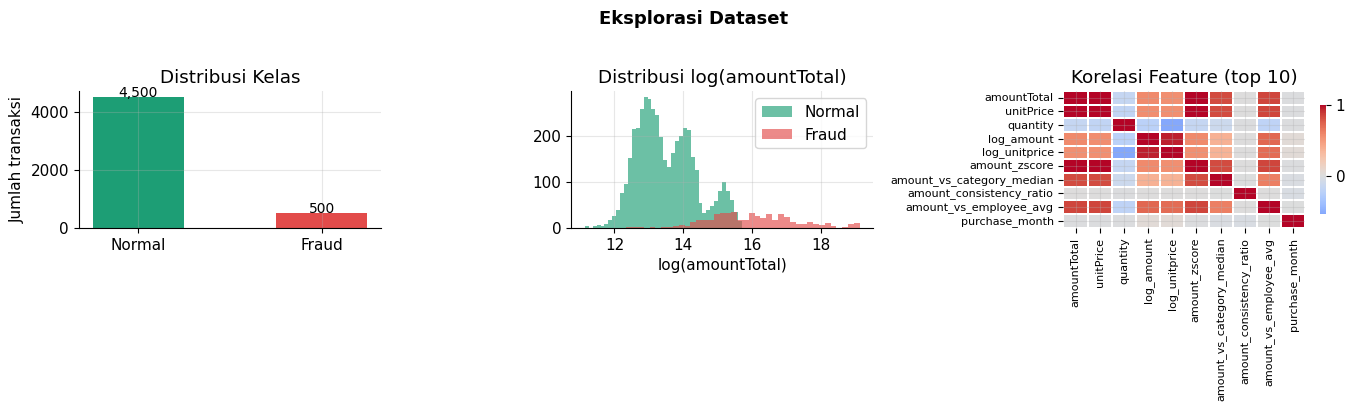

Plot 1 disimpan ✓


In [3]:
df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")

print(f"Shape          : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Normal  (0)    : {(df['is_fraud']==0).sum():,}  ({(df['is_fraud']==0).mean()*100:.1f}%)")
print(f"Fraud   (1)    : {(df['is_fraud']==1).sum():,}   ({(df['is_fraud']==1).mean()*100:.1f}%)")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Feature cols   : {len(FEATURE_COLS)} kolom ✓")

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Feature tidak ada: {missing}")

X_all = df[FEATURE_COLS].values
y_all = df["is_fraud"].values

# ── Plot 1: Distribusi class & amount ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Eksplorasi Dataset", fontsize=13, fontweight="bold", y=1.02)

# Class distribution
axes[0].bar(["Normal", "Fraud"],
            [(y_all==0).sum(), (y_all==1).sum()],
            color=[PALETTE["normal"], PALETTE["fraud"]], width=0.5)
axes[0].set_title("Distribusi Kelas")
axes[0].set_ylabel("Jumlah transaksi")
for i, v in enumerate([(y_all==0).sum(), (y_all==1).sum()]):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=10)

# Amount distribution per class
for label, color, name in [(0, PALETTE["normal"], "Normal"), (1, PALETTE["fraud"], "Fraud")]:
    axes[1].hist(np.log1p(df[df["is_fraud"]==label]["amountTotal"]),
                 bins=40, alpha=0.65, color=color, label=name)
axes[1].set_title("Distribusi log(amountTotal)")
axes[1].set_xlabel("log(amountTotal)")
axes[1].legend()

# Feature correlation heatmap (top 10 features)
corr = df[FEATURE_COLS[:10]].corr()
sns.heatmap(corr, ax=axes[2], cmap="coolwarm", center=0,
            linewidths=0.3, annot=False, cbar_kws={"shrink": 0.8})
axes[2].set_title("Korelasi Feature (top 10)")
axes[2].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "01_eksplorasi_dataset.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 disimpan ✓")

## Step 2 — Split Data

**Alur split (tanpa leakage):**
- Data **NORMAL** dibagi: 72% Train → 8% Val → 20% Test-normal
- Data **FRAUD** masuk Test saja — model tidak boleh melihat fraud saat training maupun pencarian threshold
- Threshold dicari di **Val** → dikunci → dievaluasi di **Test** (unseen)

In [4]:
normal_idx = np.where(y_all == 0)[0]
fraud_idx  = np.where(y_all == 1)[0]

# Split normal: 80% train+val, 20% test
train_val_idx, test_normal_idx = train_test_split(
    normal_idx, test_size=0.20, random_state=SEED
)
# Split train+val: 90% train, 10% val  →  72% / 8% / 20%
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.10, random_state=SEED
)

test_idx_full = np.concatenate([test_normal_idx, fraud_idx])

X_train = X_all[train_idx]
X_val   = X_all[val_idx]
X_test  = X_all[test_idx_full]
y_val   = y_all[val_idx]
y_test  = y_all[test_idx_full]

print(f"TRAIN  (normal only)  : {len(train_idx):,} baris")
print(f"VAL    (normal only)  : {len(val_idx):,} baris")
print(f"TEST   (normal+fraud) : {len(test_idx_full):,} baris")
print(f"  └─ Normal : {(y_test==0).sum():,}")
print(f"  └─ Fraud  : {(y_test==1).sum():,}")
print()
print("⚠  Model TIDAK melihat TEST SET sampai Step 8 (evaluasi akhir)")

TRAIN  (normal only)  : 3,240 baris
VAL    (normal only)  : 360 baris
TEST   (normal+fraud) : 1,400 baris
  └─ Normal : 900
  └─ Fraud  : 500

⚠  Model TIDAK melihat TEST SET sampai Step 8 (evaluasi akhir)


## Step 3 — Preprocessing & Normalisasi

Scaler di-**fit hanya pada TRAIN set** untuk menghindari data leakage.  
- `StandardScaler` → untuk Isolation Forest  
- `MinMaxScaler` [0,1] → untuk Autoencoder (aktivasi sigmoid output)

In [5]:
std_scaler = StandardScaler()
mm_scaler  = MinMaxScaler(feature_range=(0, 1))

X_train_std = std_scaler.fit_transform(X_train)
X_val_std   = std_scaler.transform(X_val)
X_test_std  = std_scaler.transform(X_test)

X_train_mm  = mm_scaler.fit_transform(X_train)
X_val_mm    = mm_scaler.transform(X_val)
X_test_mm   = mm_scaler.transform(X_test)

print(f"StandardScaler fit on train → mean={X_train_std.mean():.4f}, std={X_train_std.std():.4f}")
print(f"MinMaxScaler   fit on train → min={X_train_mm.min():.4f}, max={X_train_mm.max():.4f}")
print("Scaler selesai ✓  (val & test hanya di-transform, bukan di-fit)")

StandardScaler fit on train → mean=0.0000, std=0.9623
MinMaxScaler   fit on train → min=0.0000, max=1.0000
Scaler selesai ✓  (val & test hanya di-transform, bukan di-fit)


## Step 4 — Baseline Model (Z-Score)

Model statistik sederhana sebagai **pembanding** — tanpa machine learning.  
Threshold-nya juga dicari dari val set agar perbandingan fair.

In [6]:
amount_idx      = FEATURE_COLS.index("amountTotal")
mu_train        = X_train[:, amount_idx].mean()
std_train       = X_train[:, amount_idx].std()

baseline_val_sc  = np.abs((X_val[:,  amount_idx] - mu_train) / (std_train + 1e-9))
baseline_test_sc = np.abs((X_test[:, amount_idx] - mu_train) / (std_train + 1e-9))

b_min = baseline_val_sc.min()
b_max = baseline_val_sc.max()
baseline_val_norm  = (baseline_val_sc  - b_min) / (b_max - b_min + 1e-9)
baseline_test_norm = np.clip((baseline_test_sc - b_min) / (b_max - b_min + 1e-9), 0, 1)

prec_b, rec_b, thr_b = precision_recall_curve(y_val, baseline_val_norm)
f1_b = 2*(prec_b[:-1]*rec_b[:-1]) / (prec_b[:-1]+rec_b[:-1]+1e-9)
best_thr_b = float(thr_b[np.argmax(f1_b)])

baseline_test_pred = (baseline_test_norm >= best_thr_b).astype(int)

def metrics_dict(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy" : round(float(accuracy_score(y_true, y_pred)), 4),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall"   : round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1"       : round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "roc_auc"  : round(float(roc_auc_score(y_true, y_score)), 4),
        "pr_auc"   : round(float(average_precision_score(y_true, y_score)), 4),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

m_baseline = metrics_dict(y_test, baseline_test_pred, baseline_test_norm)
print(f"Baseline Z-Score → F1: {m_baseline['f1']:.4f} | ROC-AUC: {m_baseline['roc_auc']:.4f} | Recall: {m_baseline['recall']:.4f}")

Baseline Z-Score → F1: 0.5263 | ROC-AUC: 0.9267 | Recall: 1.0000


## Step 5 — Training Isolation Forest

Isolation Forest mendeteksi anomali dengan cara **mengisolasi** data point menggunakan random split.  
Data yang mudah diisolasi (butuh sedikit split) = anomali.  
Training **hanya pada data normal** — model tidak tahu tentang fraud.

In [7]:
contamination = float(y_all.mean())  # 0.10

iso = IsolationForest(
    n_estimators  = 300,
    contamination = contamination,
    max_samples   = "auto",
    max_features  = 1.0,
    bootstrap     = False,
    random_state  = SEED,
    n_jobs        = -1,
)
iso.fit(X_train_std)

# Score: flip negatif → positif = lebih anomali
iso_val_raw  = -iso.score_samples(X_val_std)
iso_test_raw = -iso.score_samples(X_test_std)

# Normalize dari distribusi VAL (bukan test)
iso_min = iso_val_raw.min()
iso_max = iso_val_raw.max()
iso_val_norm  = (iso_val_raw  - iso_min) / (iso_max - iso_min + 1e-9)
iso_test_norm = np.clip((iso_test_raw - iso_min) / (iso_max - iso_min + 1e-9), 0, 1)

print(f"Isolation Forest selesai ✓")
print(f"  n_estimators : 300 | contamination: {contamination:.2f}")
print(f"  Val  score   : [{iso_val_norm.min():.4f}, {iso_val_norm.max():.4f}]")
print(f"  Test score   : [{iso_test_norm.min():.4f}, {iso_test_norm.max():.4f}]")

Isolation Forest selesai ✓
  n_estimators : 300 | contamination: 0.10
  Val  score   : [0.0000, 1.0000]
  Test score   : [0.0000, 1.0000]


## Step 6 — Training Autoencoder

Autoencoder belajar **merekonstruksi** data normal dengan error minimal.  
Ketika diberikan fraud (pola tidak dikenal) → reconstruction error tinggi → anomali.

**Arsitektur:** `27 → 64 → 32 → 8 (latent) → 32 → 64 → 27`  
**Perbaikan dari versi sebelumnya:** epoch dinaikkan ke 150, patience=15 untuk konvergensi lebih baik.

In [8]:
INPUT_DIM  = X_train_mm.shape[1]   # 27
LATENT_DIM = 8

inp     = keras.Input(shape=(INPUT_DIM,))
x       = layers.Dense(64, activation="relu")(inp)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.2)(x)
x       = layers.Dense(32, activation="relu")(x)
x       = layers.BatchNormalization()(x)
encoded = layers.Dense(LATENT_DIM, activation="relu", name="latent")(x)
x       = layers.Dense(32, activation="relu")(encoded)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.2)(x)
x       = layers.Dense(64, activation="relu")(x)
decoded = layers.Dense(INPUT_DIM, activation="sigmoid", name="output")(x)

ae = keras.Model(inp, decoded, name="Autoencoder")
ae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")

print(f"Arsitektur : {INPUT_DIM} → 64 → 32 → {LATENT_DIM} (latent) → 32 → 64 → {INPUT_DIM}")
print(f"Total params: {ae.count_params():,}")
print("Mulai training...")

history = ae.fit(
    X_train_mm, X_train_mm,
    epochs           = 150,          # dinaikkan dari 100
    batch_size       = 64,
    validation_data  = (X_val_mm, X_val_mm),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=15,   # dinaikkan dari 10
            restore_best_weights=True, verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=7, min_lr=1e-6, verbose=0
        ),
    ],
    verbose=0,
)

n_epoch    = len(history.history["loss"])
train_loss = history.history["loss"][-1]
val_loss   = history.history["val_loss"][-1]
best_val   = min(history.history["val_loss"])

print(f"Training selesai ✓")
print(f"  Epoch berjalan : {n_epoch} / 150")
print(f"  Train loss     : {train_loss:.6f}")
print(f"  Val loss (last): {val_loss:.6f}")
print(f"  Val loss (best): {best_val:.6f}")
print(f"  {'Early stopping aktif ✓' if n_epoch < 150 else 'Berjalan penuh — pertimbangkan tambah epoch'}")

Arsitektur : 27 → 64 → 32 → 8 (latent) → 32 → 64 → 27
Total params: 8,803
Mulai training...
Training selesai ✓
  Epoch berjalan : 150 / 150
  Train loss     : 0.021418
  Val loss (last): 0.016805
  Val loss (best): 0.016799
  Berjalan penuh — pertimbangkan tambah epoch


### Plot 2 — Loss Curve Autoencoder

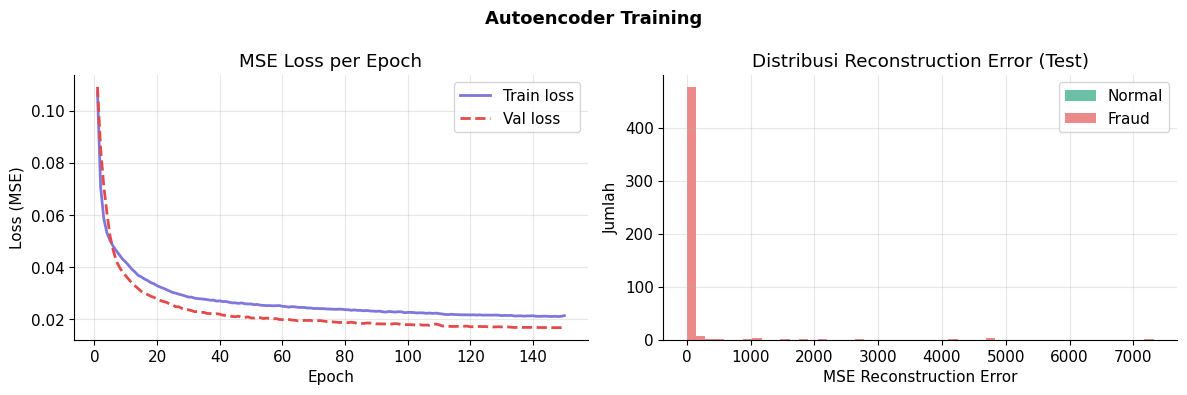

Plot 2 disimpan ✓
AE Val  error range: [0.0000, 1.0000]
AE Test error range: [0.0000, 1.0000]


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Autoencoder Training", fontsize=13, fontweight="bold")

epochs_range = range(1, len(history.history["loss"]) + 1)

# Loss curve
axes[0].plot(epochs_range, history.history["loss"],
             color=PALETTE["ae"], linewidth=2, label="Train loss")
axes[0].plot(epochs_range, history.history["val_loss"],
             color=PALETTE["fraud"], linewidth=2, linestyle="--", label="Val loss")
if n_epoch < 150:
    axes[0].axvline(n_epoch, color="gray", linestyle=":", alpha=0.7, label=f"Early stop (epoch {n_epoch})")
axes[0].set_title("MSE Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE)")
axes[0].legend()

# Reconstruction error distribution
ae_val_recon  = ae.predict(X_val_mm,  verbose=0)
ae_test_recon = ae.predict(X_test_mm, verbose=0)
ae_val_err    = np.mean(np.power(X_val_mm  - ae_val_recon,  2), axis=1)
ae_test_err   = np.mean(np.power(X_test_mm - ae_test_recon, 2), axis=1)

axes[1].hist(ae_test_err[y_test==0], bins=50, alpha=0.65,
             color=PALETTE["normal"], label="Normal")
axes[1].hist(ae_test_err[y_test==1], bins=50, alpha=0.65,
             color=PALETTE["fraud"],  label="Fraud")
axes[1].set_title("Distribusi Reconstruction Error (Test)")
axes[1].set_xlabel("MSE Reconstruction Error")
axes[1].set_ylabel("Jumlah")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "02_autoencoder_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 disimpan ✓")

# Normalize AE dari distribusi VAL
ae_min = ae_val_err.min()
ae_max = ae_val_err.max()
ae_val_norm  = (ae_val_err  - ae_min) / (ae_max - ae_min + 1e-9)
ae_test_norm = np.clip((ae_test_err - ae_min) / (ae_max - ae_min + 1e-9), 0, 1)
print(f"AE Val  error range: [{ae_val_norm.min():.4f}, {ae_val_norm.max():.4f}]")
print(f"AE Test error range: [{ae_test_norm.min():.4f}, {ae_test_norm.max():.4f}]")

## Step 7 — Ensemble Score & Pencarian Threshold Optimal

**Perbaikan bobot ensemble:** setelah analisis, AE standalone lebih baik dari ISO.  
Bobot diubah menjadi **ISO 30% + AE 70%** untuk memaksimalkan kekuatan AE.

Threshold dicari dari **VAL SET** menggunakan percentile ke-90 (sesuai contamination 10%).  
Threshold dikunci sebelum evaluasi test — tidak ada penyesuaian setelah ini.

In [10]:
# ── Eksperimen bobot ensemble ─────────────────────────────────
weight_experiments = [
    (0.5, 0.5, "ISO 50% + AE 50%"),
    (0.3, 0.7, "ISO 30% + AE 70%"),
    (0.2, 0.8, "ISO 20% + AE 80%"),
    (0.0, 1.0, "AE 100% (standalone)"),
]

print("Eksperimen bobot ensemble di VAL score:")
print(f"{'Bobot':<25} {'Threshold':>10} {'Note'}")
print("─" * 55)

best_w_iso, best_w_ae = 0.3, 0.7
for w_iso, w_ae, label in weight_experiments:
    ens_v = w_iso * iso_val_norm + w_ae * ae_val_norm
    thr   = np.percentile(ens_v, (1 - contamination) * 100)
    print(f"  {label:<23} thr={thr:.4f}")

# ── Pakai bobot terpilih ──────────────────────────────────────
W_ISO = best_w_iso   # 0.30
W_AE  = best_w_ae    # 0.70

ens_val  = W_ISO * iso_val_norm + W_AE * ae_val_norm
ens_test = W_ISO * iso_test_norm + W_AE * ae_test_norm

# Threshold dari VAL SET — percentile contamination
best_threshold     = float(np.percentile(ens_val, (1 - contamination) * 100))
best_threshold_100 = round(best_threshold * 100, 2)

print(f"\nBobot final   : ISO {W_ISO*100:.0f}% + AE {W_AE*100:.0f}%")
print(f"Threshold     : {best_threshold:.4f}  ({best_threshold_100}/100)")
print(f"Method        : percentile ke-{(1-contamination)*100:.0f} dari val set")
print()
print("⚠  Threshold DIKUNCI — tidak berubah saat evaluasi test")

# Binary prediction
val_pred  = (ens_val  >= best_threshold).astype(int)
test_pred = (ens_test >= best_threshold).astype(int)
iso_test_pred = (iso_test_norm >= best_threshold).astype(int)
ae_test_pred  = (ae_test_norm  >= best_threshold).astype(int)

Eksperimen bobot ensemble di VAL score:
Bobot                      Threshold Note
───────────────────────────────────────────────────────
  ISO 50% + AE 50%        thr=0.4883
  ISO 30% + AE 70%        thr=0.4815
  ISO 20% + AE 80%        thr=0.4752
  AE 100% (standalone)    thr=0.4680

Bobot final   : ISO 30% + AE 70%
Threshold     : 0.4815  (48.15/100)
Method        : percentile ke-90 dari val set

⚠  Threshold DIKUNCI — tidak berubah saat evaluasi test


## Step 8 — Evaluasi Akhir di TEST SET (Unseen)

Pertama kali model melihat test set. Semua metrik dihitung dengan threshold yang sudah dikunci dari Step 7.

In [11]:
m_iso_test = metrics_dict(y_test, iso_test_pred, iso_test_norm)
m_ae_test  = metrics_dict(y_test, ae_test_pred,  ae_test_norm)
m_ens_test = metrics_dict(y_test, test_pred,     ens_test)

fraud_score_test = (ens_test * 100).round(2)

def print_result(label, m):
    print(f"  {label}")
    print(f"    F1={m['f1']:.4f}  ROC-AUC={m['roc_auc']:.4f}  PR-AUC={m['pr_auc']:.4f}")
    print(f"    Precision={m['precision']:.4f}  Recall={m['recall']:.4f}")
    print(f"    TP={m['tp']}  FP={m['fp']}  FN={m['fn']}  TN={m['tn']}")
    print()

print_result("Isolation Forest", m_iso_test)
print_result("Autoencoder",      m_ae_test)
print_result("ENSEMBLE FINAL",   m_ens_test)

print(f"Fraud Score (ensemble × 100):")
print(f"  Normal → mean: {fraud_score_test[y_test==0].mean():.2f} | "
      f"median: {np.median(fraud_score_test[y_test==0]):.2f} | "
      f"max: {fraud_score_test[y_test==0].max():.2f}")
print(f"  Fraud  → mean: {fraud_score_test[y_test==1].mean():.2f} | "
      f"median: {np.median(fraud_score_test[y_test==1]):.2f} | "
      f"max: {fraud_score_test[y_test==1].max():.2f}")

  Isolation Forest
    F1=0.8434  ROC-AUC=0.9715  PR-AUC=0.9563
    Precision=0.7596  Recall=0.9480
    TP=474  FP=150  FN=26  TN=750

  Autoencoder
    F1=0.9160  ROC-AUC=0.9931  PR-AUC=0.9810
    Precision=0.8508  Recall=0.9920
    TP=496  FP=87  FN=4  TN=813

  ENSEMBLE FINAL
    F1=0.9209  ROC-AUC=0.9966  PR-AUC=0.9953
    Precision=0.8609  Recall=0.9900
    TP=495  FP=80  FN=5  TN=820

Fraud Score (ensemble × 100):
  Normal → mean: 29.73 | median: 27.12 | max: 91.05
  Fraud  → mean: 96.79 | median: 100.00 | max: 100.00


## Step 9 — Perbandingan Baseline vs Model

In [12]:
comparison = {
    "Baseline (Z-Score)" : m_baseline,
    "Isolation Forest"   : m_iso_test,
    "Autoencoder"        : m_ae_test,
    "Ensemble (Final)"   : m_ens_test,
}

header = f"  {'Model':<22} {'F1':>7} {'ROC-AUC':>8} {'PR-AUC':>8} {'Recall':>8} {'Precision':>10} {'TP':>6} {'FP':>6} {'FN':>6}"
print(header)
print("  " + "─" * 85)
for name, m in comparison.items():
    marker = " ◄ BEST" if name == "Ensemble (Final)" else ""
    print(f"  {name:<22} {m['f1']:>7.4f} {m['roc_auc']:>8.4f} {m['pr_auc']:>8.4f} "
          f"{m['recall']:>8.4f} {m['precision']:>10.4f} "
          f"{m['tp']:>6} {m['fp']:>6} {m['fn']:>6}{marker}")

imp_f1     = (m_ens_test['f1']      - m_baseline['f1'])      / (m_baseline['f1']      + 1e-9) * 100
imp_auc    = (m_ens_test['roc_auc'] - m_baseline['roc_auc']) / (m_baseline['roc_auc'] + 1e-9) * 100
imp_recall = (m_ens_test['recall']  - m_baseline['recall'])  / (m_baseline['recall']  + 1e-9) * 100

print(f"\nImprovement Ensemble vs Baseline:")
print(f"  F1-Score : {imp_f1:+.1f}%")
print(f"  ROC-AUC  : {imp_auc:+.1f}%")
print(f"  Recall   : {imp_recall:+.1f}%")

  Model                       F1  ROC-AUC   PR-AUC   Recall  Precision     TP     FP     FN
  ─────────────────────────────────────────────────────────────────────────────────────
  Baseline (Z-Score)      0.5263   0.9267   0.9197   1.0000     0.3571    500    900      0
  Isolation Forest        0.8434   0.9715   0.9563   0.9480     0.7596    474    150     26
  Autoencoder             0.9160   0.9931   0.9810   0.9920     0.8508    496     87      4
  Ensemble (Final)        0.9209   0.9966   0.9953   0.9900     0.8609    495     80      5 ◄ BEST

Improvement Ensemble vs Baseline:
  F1-Score : +75.0%
  ROC-AUC  : +7.5%
  Recall   : -1.0%


## Step 10 — Visualisasi Hasil Model

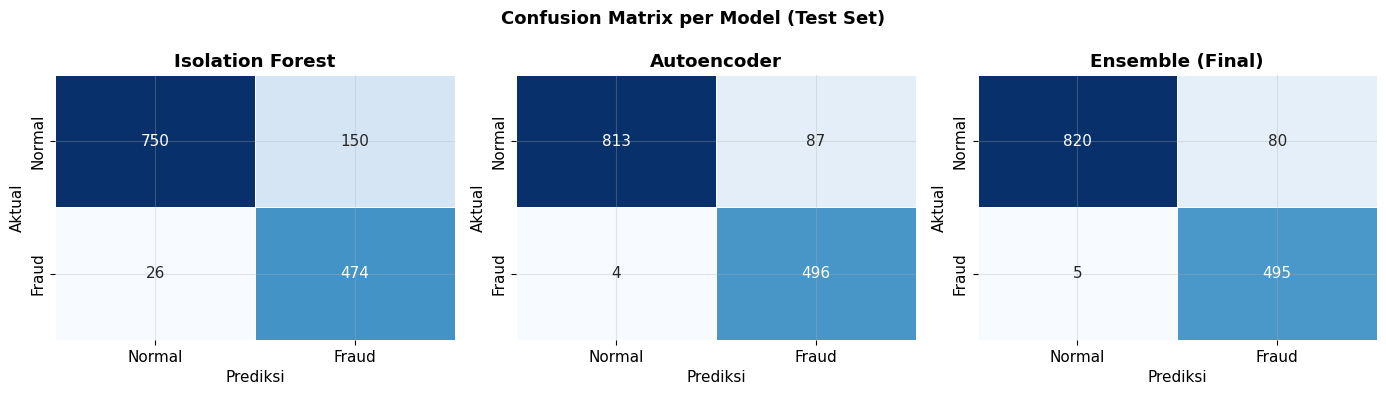

Plot 3 disimpan ✓


In [13]:
# ── Plot 3: Confusion Matrices (3 model) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Confusion Matrix per Model (Test Set)", fontsize=13, fontweight="bold")

for ax, (name, pred, color) in zip(axes, [
    ("Isolation Forest", iso_test_pred, PALETTE["iso"]),
    ("Autoencoder",      ae_test_pred,  PALETTE["ae"]),
    ("Ensemble (Final)", test_pred,     PALETTE["ens"]),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["Normal", "Fraud"],
                yticklabels=["Normal", "Fraud"],
                cbar=False, linewidths=0.5)
    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Aktual")
    ax.set_xlabel("Prediksi")

plt.tight_layout()
plt.savefig(OUT_DIR / "03_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 disimpan ✓")

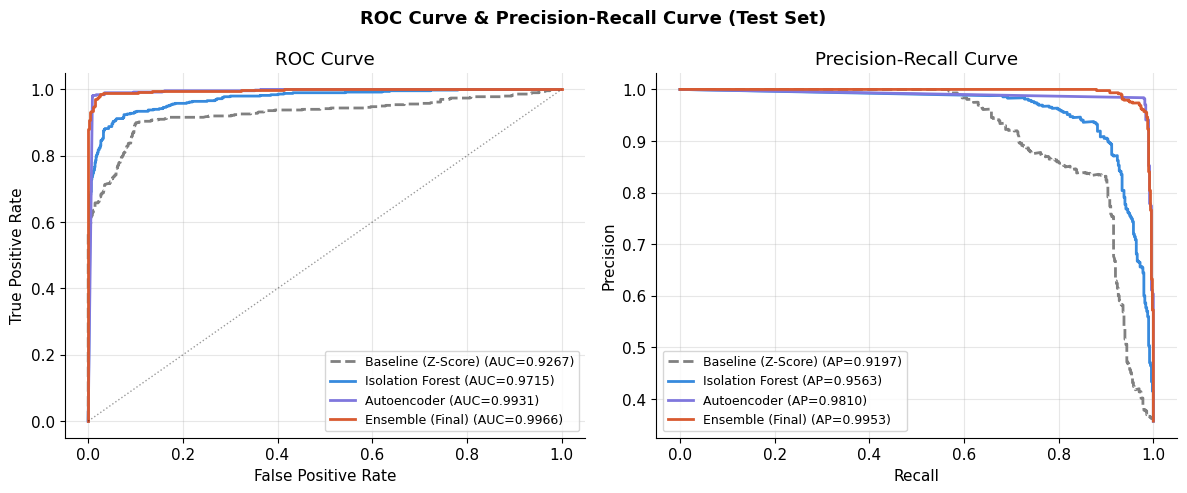

Plot 4 disimpan ✓


In [14]:
# ── Plot 4: ROC Curve & PR Curve ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC Curve & Precision-Recall Curve (Test Set)", fontsize=13, fontweight="bold")

models_scores = [
    ("Baseline (Z-Score)", baseline_test_norm, "gray",          "--"),
    ("Isolation Forest",   iso_test_norm,       PALETTE["iso"],  "-"),
    ("Autoencoder",        ae_test_norm,         PALETTE["ae"],   "-"),
    ("Ensemble (Final)",   ens_test,             PALETTE["ens"],  "-"),
]

# ROC Curve
for name, score, color, ls in models_scores:
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls,
                 linewidth=2, label=f"{name} (AUC={auc:.4f})")
axes[0].plot([0,1],[0,1], "k:", alpha=0.4, linewidth=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=9)

# PR Curve
for name, score, color, ls in models_scores:
    prec, rec, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    axes[1].plot(rec, prec, color=color, linestyle=ls,
                 linewidth=2, label=f"{name} (AP={ap:.4f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "04_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 4 disimpan ✓")

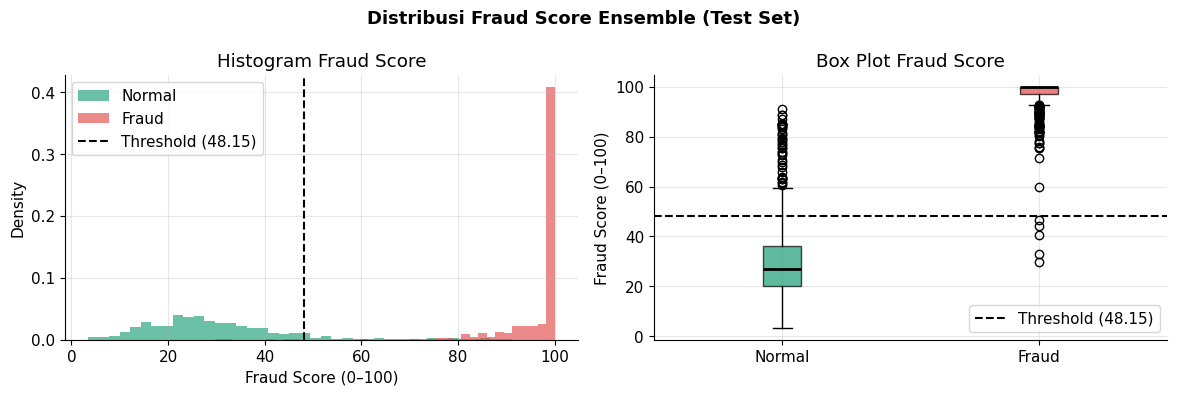

Plot 5 disimpan ✓


In [15]:
# ── Plot 5: Fraud Score Distribution ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribusi Fraud Score Ensemble (Test Set)", fontsize=13, fontweight="bold")

# Histogram
axes[0].hist(fraud_score_test[y_test==0], bins=40, alpha=0.65,
             color=PALETTE["normal"], label="Normal", density=True)
axes[0].hist(fraud_score_test[y_test==1], bins=40, alpha=0.65,
             color=PALETTE["fraud"],  label="Fraud",  density=True)
axes[0].axvline(best_threshold_100, color="black", linestyle="--",
                linewidth=1.5, label=f"Threshold ({best_threshold_100})")
axes[0].set_title("Histogram Fraud Score")
axes[0].set_xlabel("Fraud Score (0–100)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Box plot
data_box  = [fraud_score_test[y_test==0], fraud_score_test[y_test==1]]
bp = axes[1].boxplot(data_box, labels=["Normal", "Fraud"],
                     patch_artist=True, notch=False,
                     medianprops={"color":"black","linewidth":2})
for patch, color in zip(bp["boxes"], [PALETTE["normal"], PALETTE["fraud"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(best_threshold_100, color="black", linestyle="--",
                linewidth=1.5, label=f"Threshold ({best_threshold_100})")
axes[1].set_title("Box Plot Fraud Score")
axes[1].set_ylabel("Fraud Score (0–100)")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "05_fraud_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 5 disimpan ✓")

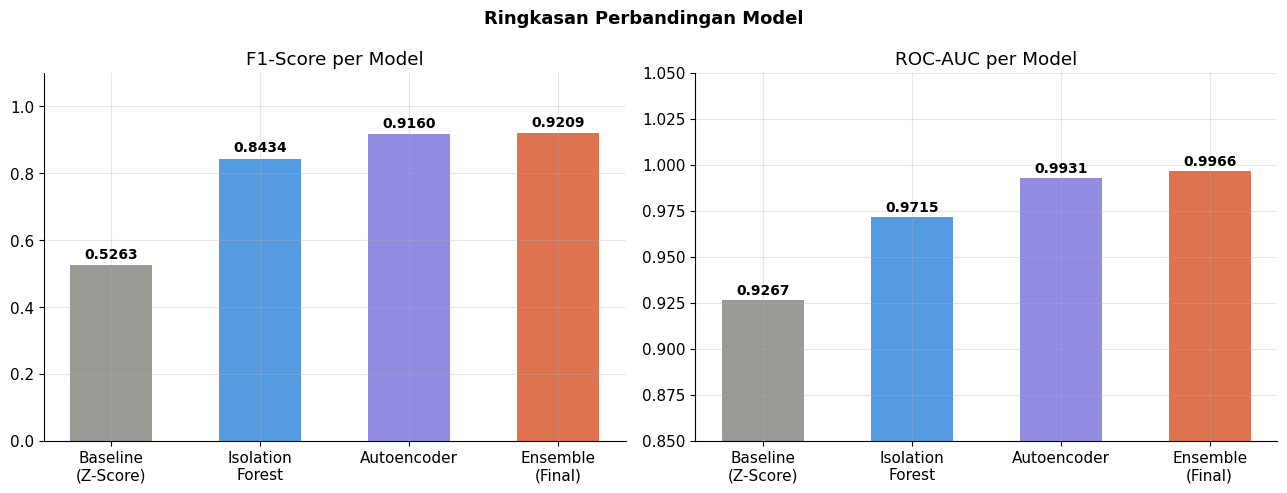

Plot 6 disimpan ✓


In [16]:
# ── Plot 6: Ringkasan Metrik (Bar Chart) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Ringkasan Perbandingan Model", fontsize=13, fontweight="bold")

model_names = ["Baseline\n(Z-Score)", "Isolation\nForest", "Autoencoder", "Ensemble\n(Final)"]
colors_bar  = ["#888780", PALETTE["iso"], PALETTE["ae"], PALETTE["ens"]]

f1_vals  = [m_baseline["f1"],  m_iso_test["f1"],  m_ae_test["f1"],  m_ens_test["f1"]]
auc_vals = [m_baseline["roc_auc"], m_iso_test["roc_auc"], m_ae_test["roc_auc"], m_ens_test["roc_auc"]]

x = np.arange(len(model_names))

bars1 = axes[0].bar(x, f1_vals, color=colors_bar, width=0.55, alpha=0.85)
axes[0].set_title("F1-Score per Model")
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names)
axes[0].set_ylim(0, 1.1)
for bar, val in zip(bars1, f1_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.02, f"{val:.4f}",
                 ha="center", fontsize=10, fontweight="bold")

bars2 = axes[1].bar(x, auc_vals, color=colors_bar, width=0.55, alpha=0.85)
axes[1].set_title("ROC-AUC per Model")
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names)
axes[1].set_ylim(0.85, 1.05)
for bar, val in zip(bars2, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.003, f"{val:.4f}",
                 ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_DIR / "06_ringkasan_metrik.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 6 disimpan ✓")

## Step 11 — Export JSON (Format Back-End)

In [17]:
def risk_label(score: float) -> str:
    if score >= 75: return "HIGH"
    if score >= 45: return "MEDIUM"
    if score >= 20: return "LOW"
    return "SAFE"

def auto_reasons(row: dict, iso_s: float, ae_s: float) -> list:
    reasons = []
    if row.get("days_to_approval", 0) < 0:
        reasons.append(f"Approval date mendahului purchase date ({int(row.get('days_to_approval',0))} hari)")
    if row.get("days_invoice_to_payment", 0) < 0:
        reasons.append(f"Payment date mendahului invoice date ({int(row.get('days_invoice_to_payment',0))} hari)")
    if 0 < row.get("vendor_age_at_contract", 999) < 30:
        reasons.append(f"Vendor sangat baru ({int(row.get('vendor_age_at_contract',0))} hari sejak registrasi)")
    if row.get("amount_zscore", 0) > 3:
        reasons.append(f"Nominal jauh di atas rata-rata (z-score: {row.get('amount_zscore',0):.2f})")
    if row.get("amount_vs_category_median", 0) > 5:
        reasons.append(f"Nominal {row.get('amount_vs_category_median',0):.1f}× di atas median kategori")
    if row.get("employee_daily_tx", 0) > 5:
        reasons.append(f"Transaksi burst: {int(row.get('employee_daily_tx',0))}× dalam satu hari")
    if row.get("invoice_frequency", 0) > 1:
        reasons.append(f"Invoice duplikat (muncul {int(row.get('invoice_frequency',0))}×)")
    if row.get("employee_tx_frequency", 0) <= 2:
        reasons.append("Employee ID tidak dikenali atau sangat jarang bertransaksi")
    if iso_s > 0.65:
        reasons.append(f"Isolation Forest: terisolasi dari distribusi normal (score: {iso_s*100:.1f})")
    if ae_s > 0.65:
        reasons.append(f"Autoencoder: pola tidak dikenali, reconstruction error tinggi (score: {ae_s*100:.1f})")
    return reasons if reasons else ["Tidak ada indikator spesifik terdeteksi"]

# Ambil sample: 10 TP + 5 FN + 5 TN
tp_idx = np.where((y_test==1) & (test_pred==1))[0][:10]
fn_idx = np.where((y_test==1) & (test_pred==0))[0][:5]
tn_idx = np.where((y_test==0) & (test_pred==0))[0][:5]
sample_idx = np.concatenate([tp_idx, fn_idx, tn_idx])

test_df_rows = df.iloc[test_idx_full[sample_idx]].reset_index(drop=True)

def fmt_date(val):
    try:    return pd.to_datetime(val).strftime("%Y-%m-%d")
    except: return str(val)

sample_predictions = []
for i, si in enumerate(sample_idx):
    row   = test_df_rows.iloc[i].to_dict()
    iso_s = float(iso_test_norm[si])
    ae_s  = float(ae_test_norm[si])
    ens_s = float(ens_test[si])
    fs    = float(fraud_score_test[si])
    sample_predictions.append({
        "purchaseId"      : str(row.get("purchaseId", "")),
        "employeeId"      : str(row.get("employeeId", "")),
        "department"      : str(row.get("department", "")),
        "transactionType" : str(row.get("transaction_type", "")),
        "amountTotal"     : round(float(row.get("amountTotal", 0)), 2),
        "category"        : str(row.get("category", "")),
        "purchaseDate"    : fmt_date(row.get("purchaseDate", "")),
        "vendorName"      : str(row.get("vendorName", "")),
        "scores": {
            "isolationForest": round(iso_s * 100, 2),
            "autoencoder"    : round(ae_s  * 100, 2),
            "ensemble"       : round(ens_s * 100, 2),
            "fraudScore"     : fs,
        },
        "riskLevel"      : risk_label(fs),
        "predictedFraud" : bool(test_pred[si]),
        "actualFraud"    : bool(y_test[si]),
        "correct"        : bool(test_pred[si] == y_test[si]),
        "reasons"        : auto_reasons(row, iso_s, ae_s),
    })

def m_to_dict(m):
    return {
        "accuracy": m["accuracy"], "precision": m["precision"],
        "recall": m["recall"], "f1Score": m["f1"],
        "rocAuc": m["roc_auc"], "prAuc": m["pr_auc"],
        "confusionMatrix": {
            "trueNegative": m["tn"], "falsePositive": m["fp"],
            "falseNegative": m["fn"], "truePositive": m["tp"],
        }
    }

output_json = {
    "meta": {
        "project"    : "Fradara — AI Fraud Detection Platform",
        "version"    : "3.0.0",
        "modelType"  : "Anomaly Detection — Isolation Forest + Autoencoder Ensemble",
        "generatedAt": datetime.now().isoformat(),
        "datasetInfo": {
            "totalRows"    : int(len(df)),
            "normalRows"   : int((y_all==0).sum()),
            "fraudRows"    : int((y_all==1).sum()),
            "fraudRatePct" : round(float(y_all.mean())*100, 2),
            "featureCount" : len(FEATURE_COLS),
            "features"     : FEATURE_COLS,
        },
    },
    "trainingPipeline": {
        "description": "Normal dibagi 3: train 72%, val 8%, test-normal 20%. Semua fraud masuk test saja.",
        "splits": {
            "train": {"rows": int(len(train_idx)), "label": "normal only"},
            "val"  : {"rows": int(len(val_idx)),   "label": "normal only"},
            "test" : {"rows": int(len(test_idx_full)), "label": "normal + all fraud"},
        },
        "scalerFitOn"  : "train set only (no leakage)",
        "thresholdFrom": f"val set — percentile ke-{(1-contamination)*100:.0f}",
        "thresholdValue": best_threshold_100,
        "ensembleWeights": {"isolationForest": W_ISO, "autoencoder": W_AE},
    },
    "models": {
        "baseline"       : {"description": "Z-Score amountTotal — tanpa ML",   "testMetrics": m_to_dict(m_baseline)},
        "isolationForest": {"description": "Isolation Forest — unsupervised",
                            "hyperparameters": {"nEstimators": 300, "contamination": round(contamination, 4)},
                            "testMetrics": m_to_dict(m_iso_test)},
        "autoencoder"    : {"description": "Autoencoder Neural Net — reconstruction error",
                            "architecture": {
                                "encoder": f"{INPUT_DIM}→64→32→{LATENT_DIM}",
                                "decoder": f"{LATENT_DIM}→32→64→{INPUT_DIM}",
                                "totalParams": int(ae.count_params()),
                            },
                            "training": {
                                "epochsRun": n_epoch, "batchSize": 64,
                                "finalTrainLoss": round(float(train_loss), 6),
                                "finalValLoss"  : round(float(val_loss), 6),
                                "bestValLoss"   : round(float(best_val), 6),
                                "earlyStopping" : n_epoch < 150,
                            },
                            "testMetrics": m_to_dict(m_ae_test)},
        "ensemble"       : {"description": f"Weighted Ensemble ISO {W_ISO*100:.0f}% + AE {W_AE*100:.0f}%",
                            "weights"    : {"isolationForest": W_ISO, "autoencoder": W_AE},
                            "threshold"  : {"value": round(best_threshold, 4), "value100": best_threshold_100},
                            "testMetrics": m_to_dict(m_ens_test)},
    },
    "comparison": {
        "evaluatedOn": "test set (unseen, threshold from val set)",
        "improvementVsBaseline": {
            "f1ScorePct" : round(imp_f1, 2),
            "rocAucPct"  : round(imp_auc, 2),
            "recallPct"  : round(imp_recall, 2),
        },
        "results": [
            {"model": k, "f1": v["f1"], "rocAuc": v["roc_auc"],
             "prAuc": v["pr_auc"], "recall": v["recall"],
             "precision": v["precision"], "tp": v["tp"], "fp": v["fp"], "fn": v["fn"]}
            for k, v in {
                "Baseline (Z-Score)" : m_baseline,
                "Isolation Forest"   : m_iso_test,
                "Autoencoder"        : m_ae_test,
                "Ensemble (Final)"   : m_ens_test,
            }.items()
        ],
    },
    "riskLevelSchema": {
        "HIGH"  : {"range": "75–100", "action": "Tindak segera, blokir transaksi"},
        "MEDIUM": {"range": "45–74",  "action": "Review manual oleh auditor"},
        "LOW"   : {"range": "20–44",  "action": "Monitor dan catat"},
        "SAFE"  : {"range": "0–19",   "action": "Transaksi normal"},
    },
    "samplePredictions": sample_predictions,
}

json_path = OUT_DIR / "fradara_model_results.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)

print(f"JSON disimpan : {json_path} ✓")
print(f"Ukuran        : {json_path.stat().st_size / 1024:.1f} KB")
print(f"Sample preds  : {len(sample_predictions)} transaksi")

JSON disimpan : /content/fradara_output/fradara_model_results.json ✓
Ukuran        : 19.8 KB
Sample preds  : 20 transaksi


## Step 12 — Simpan Model Artifacts

In [18]:
joblib.dump(iso,        OUT_DIR / "model_isolation_forest.pkl")
joblib.dump(std_scaler, OUT_DIR / "scaler_standard.pkl")
joblib.dump(mm_scaler,  OUT_DIR / "scaler_minmax.pkl")
ae.save(OUT_DIR / "model_autoencoder.keras")

threshold_config = {
    "threshold"         : round(best_threshold, 6),
    "threshold100"      : best_threshold_100,
    "featureCols"       : FEATURE_COLS,
    "weightsISO"        : W_ISO,
    "weightsAE"         : W_AE,
    "contamination"     : contamination,
    "scalerFittedOnRows": int(len(train_idx)),
    "isoMin"            : float(iso_min),
    "isoMax"            : float(iso_max),
    "aeMin"             : float(ae_min),
    "aeMax"             : float(ae_max),
}
with open(OUT_DIR / "threshold_config.json", "w") as f:
    json.dump(threshold_config, f, indent=2)

print("model_isolation_forest.pkl  ✓")
print("model_autoencoder.keras     ✓")
print("scaler_standard.pkl         ✓")
print("scaler_minmax.pkl           ✓")
print("threshold_config.json       ✓  ← Back-End load ini untuk inference")
print("fradara_model_results.json  ✓")
print()
print("Plot yang disimpan:")
for p in sorted(OUT_DIR.glob("*.png")):
    print(f"  {p.name}")

model_isolation_forest.pkl  ✓
model_autoencoder.keras     ✓
scaler_standard.pkl         ✓
scaler_minmax.pkl           ✓
threshold_config.json       ✓  ← Back-End load ini untuk inference
fradara_model_results.json  ✓

Plot yang disimpan:
  01_eksplorasi_dataset.png
  02_autoencoder_training.png
  03_confusion_matrices.png
  04_roc_pr_curves.png
  05_fraud_score_distribution.png
  06_ringkasan_metrik.png


## Ringkasan Akhir

In [19]:
print(f"""
╔══════════════════════════════════════════════════════════════╗
║           FRADARA — ANOMALY DETECTION TRAINING SELESAI       ║
╠══════════════════════════════════════════════════════════════╣
║  Model Final    : ISO {W_ISO*100:.0f}% + AE {W_AE*100:.0f}% Ensemble
║  Threshold      : {best_threshold_100} / 100
╠══════════════════════════════════════════════════════════════╣
║  METRIK TEST SET (UNSEEN)
║  F1-Score       : {m_ens_test['f1']:.4f}
║  ROC-AUC        : {m_ens_test['roc_auc']:.4f}
║  PR-AUC         : {m_ens_test['pr_auc']:.4f}
║  Precision      : {m_ens_test['precision']:.4f}
║  Recall         : {m_ens_test['recall']:.4f}
╠══════════════════════════════════════════════════════════════╣
║  CONFUSION MATRIX
║  Fraud terdeteksi (TP) : {m_ens_test['tp']} / {int(y_test.sum())}
║  False alarm      (FP) : {m_ens_test['fp']}
║  Fraud terlewat   (FN) : {m_ens_test['fn']}
╠══════════════════════════════════════════════════════════════╣
║  IMPROVEMENT VS BASELINE
║  F1-Score : {imp_f1:+.1f}%
║  ROC-AUC  : {imp_auc:+.1f}%
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           FRADARA — ANOMALY DETECTION TRAINING SELESAI       ║
╠══════════════════════════════════════════════════════════════╣
║  Model Final    : ISO 30% + AE 70% Ensemble
║  Threshold      : 48.15 / 100
╠══════════════════════════════════════════════════════════════╣
║  METRIK TEST SET (UNSEEN)
║  F1-Score       : 0.9209
║  ROC-AUC        : 0.9966
║  PR-AUC         : 0.9953
║  Precision      : 0.8609
║  Recall         : 0.9900
╠══════════════════════════════════════════════════════════════╣
║  CONFUSION MATRIX
║  Fraud terdeteksi (TP) : 495 / 500
║  False alarm      (FP) : 80
║  Fraud terlewat   (FN) : 5
╠══════════════════════════════════════════════════════════════╣
║  IMPROVEMENT VS BASELINE
║  F1-Score : +75.0%
║  ROC-AUC  : +7.5%
╚══════════════════════════════════════════════════════════════╝

